In [2]:
import pandas as pd
import os

In [4]:
processed_path = "../data/processed/"
# Train set
df_train_pca = pd.read_csv(os.path.join(processed_path, "df_train_pca.csv"))

# Test set
df_test_pca = pd.read_csv(os.path.join(processed_path, "df_test_pca.csv"))

# Brzi pregled
df_train_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,target
0,0.022970,-5.967714,3.897079,-2.747386,-0.085047,-0.161063,1.698362,0.300938,-3.455586,-2.220829,...,-0.859496,-1.185140,0.004086,-0.861604,-0.255883,0.775052,-0.081906,-0.206108,1.020054,1
1,-6.307603,2.776998,-2.178500,3.691180,3.078572,-2.642299,-0.326453,-1.331641,1.550033,0.049918,...,-0.351265,0.078146,0.614784,-0.527960,1.326518,2.061110,0.072384,-1.891768,0.356325,0
2,-8.326647,1.187097,-0.286650,0.333710,2.536841,-3.434837,-0.460276,-2.905680,-2.660530,-0.057532,...,-1.517514,-0.395067,-2.050341,1.111680,-0.381063,2.040566,-2.164802,1.283977,1.849358,0
3,-10.498265,1.882161,1.427111,-2.810309,-1.721857,5.795352,1.005833,1.097154,0.749268,-1.051313,...,-1.561639,1.805755,1.080687,0.417638,4.242951,-0.195641,-0.656571,-0.642841,-0.150338,0
4,7.808847,4.512286,-1.679613,3.143184,-1.941887,0.832991,-3.178764,-0.540306,-2.283444,1.685272,...,-0.173616,0.763809,-0.789098,0.671505,0.246289,-0.597793,-1.087424,-2.200030,0.208866,0


In [5]:
df_test_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,target
0,-9.334293,1.986676,3.765961,2.708791,-2.368736,0.067776,-0.130601,-1.754508,-1.315318,0.843006,...,-0.406085,-1.275452,2.499138,0.028492,1.064394,2.643639,0.641979,1.833715,-1.360819,0
1,6.476571,2.221341,3.841941,0.423201,-0.238252,0.053538,0.551522,1.885884,0.117160,-0.676968,...,-0.211489,-0.644050,0.212805,-0.801836,1.922165,0.807173,-0.158996,1.307788,-0.129138,0
2,5.051063,3.302757,3.702442,1.457333,-0.857868,1.247921,-1.986760,1.718034,-2.187353,1.476311,...,-1.922590,2.658798,-2.581072,-0.596020,2.183521,0.955168,0.114653,-1.106809,-0.169177,0
3,6.440444,3.484844,3.359795,1.751995,-1.714406,-0.409853,-3.992152,1.492438,-0.391316,-2.143872,...,0.543812,-0.272968,-2.929459,0.074060,-0.373334,3.145976,3.708359,-0.756893,0.969144,0
4,-9.538525,1.953999,1.971120,-3.419771,-1.296818,4.244512,0.901099,0.596071,-1.231705,-0.069473,...,-0.586386,-0.844646,0.335961,-0.632594,0.909917,-1.852995,-0.807652,-0.365419,-0.653273,1


In [7]:
X_train = df_train_pca.drop(columns=['target']).values
y_train = df_train_pca['target'].values

X_test  = df_test_pca.drop(columns=['target']).values
y_test  = df_test_pca['target'].values

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [10]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} treniran.")

Logistic Regression treniran.
Decision Tree treniran.
Random Forest treniran.
SVM treniran.
KNN treniran.


In [11]:
from sklearn.metrics import accuracy_score

for name, model in models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    print(f"{name}:")
    print(f"  Train accuracy: {train_acc:.4f}")
    print(f"  Test accuracy:  {test_acc:.4f}")
    print()

Logistic Regression:
  Train accuracy: 0.9727
  Test accuracy:  0.9682

Decision Tree:
  Train accuracy: 1.0000
  Test accuracy:  0.9394

Random Forest:
  Train accuracy: 1.0000
  Test accuracy:  0.9705

SVM:
  Train accuracy: 0.9920
  Test accuracy:  0.9902

KNN:
  Train accuracy: 0.9826
  Test accuracy:  0.9674



In [12]:
results = pd.DataFrame({
    "Model": ["LogReg", "Decision Tree", "Random Forest", "SVM", "KNN"],
    "Train accuracy": [0.9727, 1.0, 1.0, 0.9920, 0.9826],
    "Test accuracy": [0.9682, 0.9394, 0.9705, 0.9902, 0.9674]
})

results

,Model,Train accuracy,Test accuracy
0,LogReg,0.9727,0.9682
1,Decision Tree,1.0000,0.9394
2,Random Forest,1.0000,0.9705
3,SVM,0.9920,0.9902
4,KNN,0.9826,0.9674


U ovom koraku trenirali smo pet različitih klasifikacionih modela na PCA transformisanom skupu podataka (20 komponenti) kako bismo procijenili performanse pri predviđanju klase molekula (MUSK vs NON-MUSK).

Korišćeni modeli su: Logistic Regression, Decision Tree, Random Forest, SVM i KNN. Svi modeli su trenirani isključivo na trening skupu (df_train_pca), dok je test skup (df_test_pca) korišćen samo za evaluaciju, čime smo izbjegli problem data leakage-a.
Iz rezultata se vidi da Decision Tree pokazuje overfitting (savršena tačnost na treningu, pad na testu), dok Random Forest djelimično ublažava overfitting. Ostali modeli, posebno SVM i Logistic Regression, generalizuju dobro i pokazuju minimalni gap između trening i test skupa.

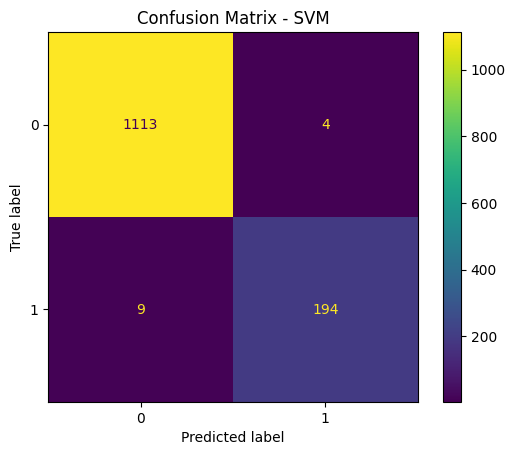

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, models["SVM"].predict(X_test))
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix - SVM")
plt.show()

In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, models["SVM"].predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1117
           1       0.98      0.96      0.97       203

    accuracy                           0.99      1320
   macro avg       0.99      0.98      0.98      1320
weighted avg       0.99      0.99      0.99      1320



In [15]:
#identifikacija najlosijeg modela
test_accuracies = {name: accuracy_score(y_test, model.predict(X_test)) for name, model in models.items()}
worst_model_name = min(test_accuracies, key=test_accuracies.get)
worst_model = models[worst_model_name]

print("Najlošiji model je:", worst_model_name, "sa test accuracy:", test_accuracies[worst_model_name])

Najlošiji model je: Decision Tree sa test accuracy: 0.9393939393939394


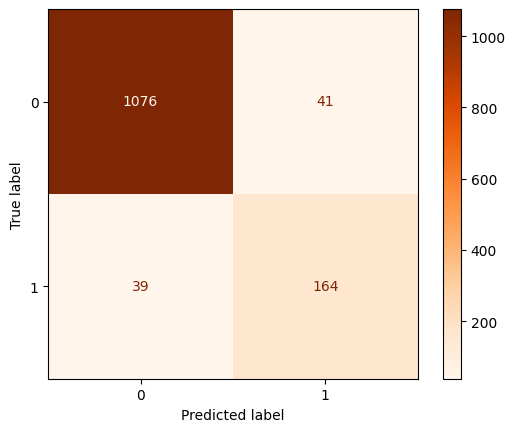

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(worst_model, X_test, y_test, cmap='Oranges')

In [17]:
print(classification_report(y_test, models["Decision Tree"].predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1117
           1       0.80      0.81      0.80       203

    accuracy                           0.94      1320
   macro avg       0.88      0.89      0.88      1320
weighted avg       0.94      0.94      0.94      1320



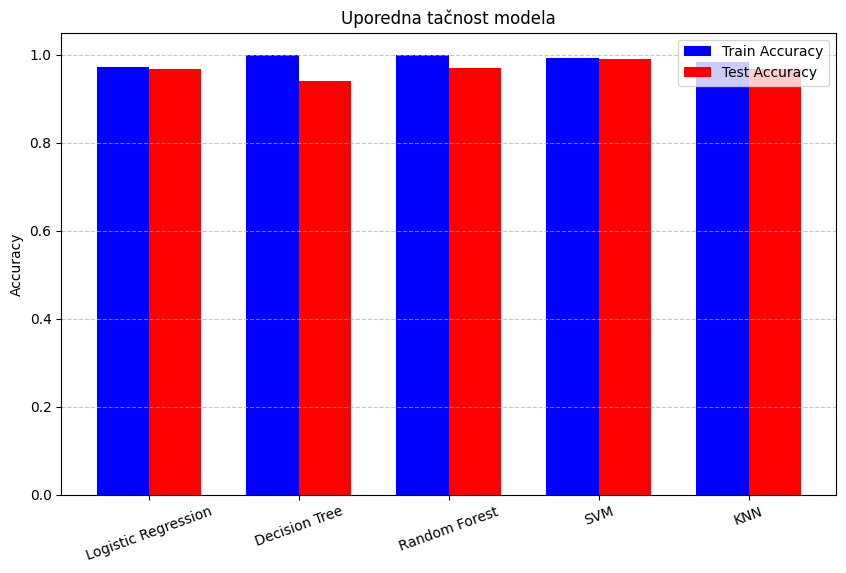

In [19]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN']
train_acc = [0.9727, 1.0, 1.0, 0.9920, 0.9826]
test_acc  = [0.9682, 0.9394, 0.9705, 0.9902, 0.9674]

x = range(len(models))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar([i - width/2 for i in x], train_acc, width=width, label='Train Accuracy', color='blue')
plt.bar([i + width/2 for i in x], test_acc, width=width, label='Test Accuracy', color='red')

plt.xticks(x, models, rotation=20)
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.title('Uporedna tačnost modela')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()